In [1]:
# Uncomment these in a fresh notebook environment.
#%pip install -r ../requirements.txt
#%pip install -e ..

In [2]:
%reload_ext autoreload
%autoreload 2

from marl_tsc.simulation_generator import SimulationGenerator, DEFAULT_TRAFFIC_LIGHT_IDS
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions
from pathlib import Path
import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = 4
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"

traffic_light_ids = list(DEFAULT_TRAFFIC_LIGHT_IDS)


In [3]:
# Compare policy results
def print_comparison_table(rows):
    columns = [
        "Policy",
        "Episodes",
        "Mean total reward",
        "Mean local queue",
        "Mean max queue",
        "Mean waiting time",
        "Mean time loss",
        "Arrived / episode",
        "Total completed steps",
        "Mean switches / episode",
    ]

    def format_value(value):
        if isinstance(value, float):
            return f"{value:.3f}"
        return str(value)

    widths = {column: len(column) for column in columns}
    for row in rows:
        for column in columns:
            widths[column] = max(widths[column], len(format_value(row.get(column, ""))))

    header = " | ".join(column.ljust(widths[column]) for column in columns)
    separator = "-+-".join("-" * widths[column] for column in columns)
    print(header)
    print(separator)
    for row in rows:
        print(" | ".join(format_value(row.get(column, "")).ljust(widths[column]) for column in columns))

## 1. Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change these values first when you want a different learning problem.


In [4]:
EPISODE_STEPS = 600  # The number of actions/steps the RL agent takes per episode
SECONDS_PER_ACTION = 5  # Matches the step logic in your SumoTrafficEnv
# The actual duration in SUMO seconds that the RL agent will experience
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION

# To ensure continuous flow, spawn vehicles for 20% longer than the simulation runs.
# This guarantees that the network never empties out or hits ACT = 0.
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)

NUM_EPISODES = 30
EVALUATION_EPISODES = 5
TOTAL_TIMESTEPS = 75_000
MIN_GREEN_SECONDS = 10
SWITCH_PENALTY = 0.5

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,  # Extends past the simulation end!
    trip_period=2,
    seed=42,
)

paths = generator.generate_all()
print(f"Generated continuous flow configuration: {paths.config_file}")
print(f"Simulation Horizon: {SIMULATION_DURATION}s | Traffic Spawning Until: {TRAFFIC_SPAWN_DURATION}s")
print("Traffic-light agents:", traffic_light_ids)

Generated continuous flow configuration: C:\Code\marl-tsc\outputs\config.sumocfg
Simulation Horizon: 3000s | Traffic Spawning Until: 3600s
Traffic-light agents: ['B1', 'B2', 'C1', 'C2']


## 2. Run the simple baselines

Random and fixed-time are useful sanity checks before training. They use the same environment and the same evaluation seeds as the learned policies.


In [5]:
def get_evaluation_results(policy):
    return evaluate_policy(
        config_file=paths.config_file,
        traffic_light_ids=traffic_light_ids,
        policy=policy,
        episodes=EVALUATION_EPISODES,
        max_steps=EPISODE_STEPS,
        seed=42,
        env_kwargs={
            "green_phase_count": GREEN_PHASE_COUNT,
            "min_green_seconds": MIN_GREEN_SECONDS,
            "seconds_per_action": SECONDS_PER_ACTION,
            "switch_penalty": SWITCH_PENALTY,
        },
    )

## 3. Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.


### PPO

[PPO] Step 2400 | Episode Return: -51.45
[PPO] Step 2400 | Episode Return: -52.69
[PPO] Step 2400 | Episode Return: -54.02
[PPO] Step 2400 | Episode Return: -51.67
[PPO] Step 4800 | Episode Return: -49.20
[PPO] Step 4800 | Episode Return: -47.41
[PPO] Step 4800 | Episode Return: -52.82
[PPO] Step 4800 | Episode Return: -47.61
[PPO] Step 7200 | Episode Return: -45.26
[PPO] Step 7200 | Episode Return: -44.96
[PPO] Step 7200 | Episode Return: -46.28
[PPO] Step 7200 | Episode Return: -43.87
[PPO] Step 9600 | Episode Return: -45.28
[PPO] Step 9600 | Episode Return: -45.24
[PPO] Step 9600 | Episode Return: -48.91
[PPO] Step 9600 | Episode Return: -46.79
[PPO] Step 12000 | Episode Return: -45.45
[PPO] Step 12000 | Episode Return: -43.75
[PPO] Step 12000 | Episode Return: -45.53
[PPO] Step 12000 | Episode Return: -44.32
[PPO] Step 14400 | Episode Return: -43.68
[PPO] Step 14400 | Episode Return: -41.77
[PPO] Step 14400 | Episode Return: -46.46
[PPO] Step 14400 | Episode Return: -42.64
[PPO] St

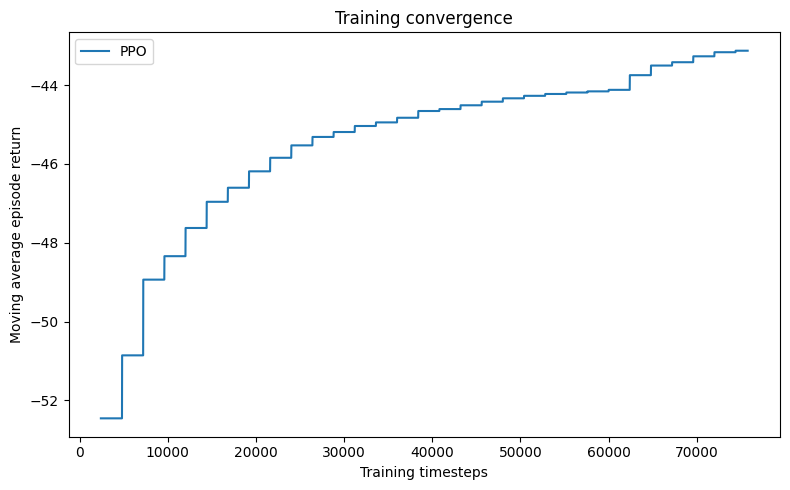

In [6]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS,
                "seconds_per_action": SECONDS_PER_ACTION,
                "switch_penalty": SWITCH_PENALTY },
)

fig, ax = plot_training_histories(ppo_history)
plt.show()

### MAPPO

[MAPPO] Episode 1 | Return: -51.33 | Total Steps: 600
[MAPPO] Episode 2 | Return: -51.19 | Total Steps: 1200
[MAPPO] Episode 3 | Return: -49.72 | Total Steps: 1800
[MAPPO] Episode 4 | Return: -50.46 | Total Steps: 2400
[MAPPO] Episode 5 | Return: -47.98 | Total Steps: 3000
[MAPPO] Episode 6 | Return: -52.01 | Total Steps: 3600
[MAPPO] Episode 7 | Return: -50.99 | Total Steps: 4200
[MAPPO] Episode 8 | Return: -48.71 | Total Steps: 4800
[MAPPO] Episode 9 | Return: -49.31 | Total Steps: 5400
[MAPPO] Episode 10 | Return: -49.91 | Total Steps: 6000
[MAPPO] Episode 11 | Return: -49.38 | Total Steps: 6600
[MAPPO] Episode 12 | Return: -50.15 | Total Steps: 7200
[MAPPO] Episode 13 | Return: -49.83 | Total Steps: 7800
[MAPPO] Episode 14 | Return: -49.54 | Total Steps: 8400
[MAPPO] Episode 15 | Return: -49.62 | Total Steps: 9000
[MAPPO] Episode 16 | Return: -49.31 | Total Steps: 9600
[MAPPO] Episode 17 | Return: -49.31 | Total Steps: 10200
[MAPPO] Episode 18 | Return: -51.87 | Total Steps: 10800


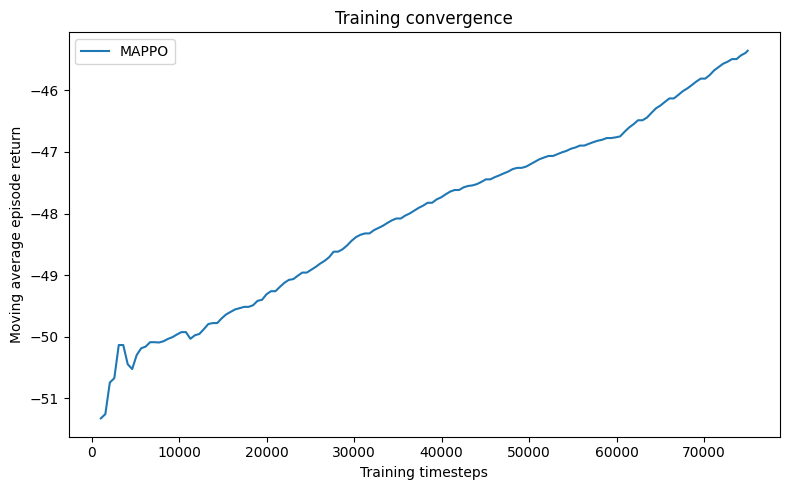

In [7]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=512,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS,
                "seconds_per_action": SECONDS_PER_ACTION,
                "switch_penalty": SWITCH_PENALTY },
)

fig, ax = plot_training_histories(mappo_history)
plt.show()

## 4. Evaluate all policies on the same seeds

The final comparison table keeps the baseline runs and adds the shared PPO and MAPPO policies on the same evaluation seeds.


In [8]:
policies = {"Random":random_actions,
           "Fixed-Time":fixed_time_actions,
           "Shared PPO":ppo_model,
           "MAPPO":mappo_model}

policy_results = {}

for name, policy in policies.items():
    print(f"Evaluating {name} model")
    policy_result = get_evaluation_results(policy)
    policy_results[name] = policy_result

Evaluating Random model
Finished Evaluation Episode 1/5 - Total Reward: -212.22
Finished Evaluation Episode 2/5 - Total Reward: -204.82
Finished Evaluation Episode 3/5 - Total Reward: -205.24
Finished Evaluation Episode 4/5 - Total Reward: -197.44
Finished Evaluation Episode 5/5 - Total Reward: -201.88
Evaluating Fixed-Time model
Finished Evaluation Episode 1/5 - Total Reward: -252.76
Finished Evaluation Episode 2/5 - Total Reward: -251.40
Finished Evaluation Episode 3/5 - Total Reward: -252.73
Finished Evaluation Episode 4/5 - Total Reward: -250.75
Finished Evaluation Episode 5/5 - Total Reward: -251.54
Evaluating Shared PPO model
Finished Evaluation Episode 1/5 - Total Reward: -186.99
Finished Evaluation Episode 2/5 - Total Reward: -187.11
Finished Evaluation Episode 3/5 - Total Reward: -186.26
Finished Evaluation Episode 4/5 - Total Reward: -189.40
Finished Evaluation Episode 5/5 - Total Reward: -186.89
Evaluating MAPPO model
Finished Evaluation Episode 1/5 - Total Reward: -186.99
F

In [9]:
# Compare all results
comparison_rows = []

for name, result in policy_results.items():
    comparison_rows.append({
        "Policy": name,
        "Episodes": result["episodes"],
        "Mean total reward": result["mean_total_reward"],
        "Mean local queue": result["mean_local_queue"],
        "Mean max queue": result["mean_max_queue"],
        "Mean waiting time": result["mean_waiting_time"],
        "Mean time loss": result["mean_total_time_loss"],
        "Arrived / episode": result["mean_arrived_vehicles_per_episode"],
        "Total completed steps": result["total_completed_steps"],
        "Mean switches / episode": result["mean_switches_per_episode"]
    })

print_comparison_table(comparison_rows)

Policy     | Episodes | Mean total reward | Mean local queue | Mean max queue | Mean waiting time | Mean time loss | Arrived / episode | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+----------------+-------------------+----------------+-------------------+-----------------------+------------------------
Random     | 5        | -204.320          | 0.427            | 6.000          | 6.476             | 1029.135       | 1462.800          | 3000                  | 785.000                
Fixed-Time | 5        | -251.836          | 0.634            | 6.400          | 13.150            | 1781.048       | 1458.200          | 3000                  | 396.000                
Shared PPO | 5        | -187.330          | 0.316            | 5.000          | 3.807             | 691.743        | 1466.600          | 3000                  | 1196.000               
MAPPO      | 5        | -187.330          | 0.316            | 5.000       